In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.max_colwidth = 150

df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df.head()

df = pd.read_csv('data/bank-additional.csv', sep = ';')
df.head()

df = pd.read_csv('data/bank-full.csv', sep = ';')
df.head()

df = pd.read_csv('data/bank.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [16]:
df.shape

(4521, 17)

In [17]:
df.rename(columns = {'y':'deposit'}, inplace = True)

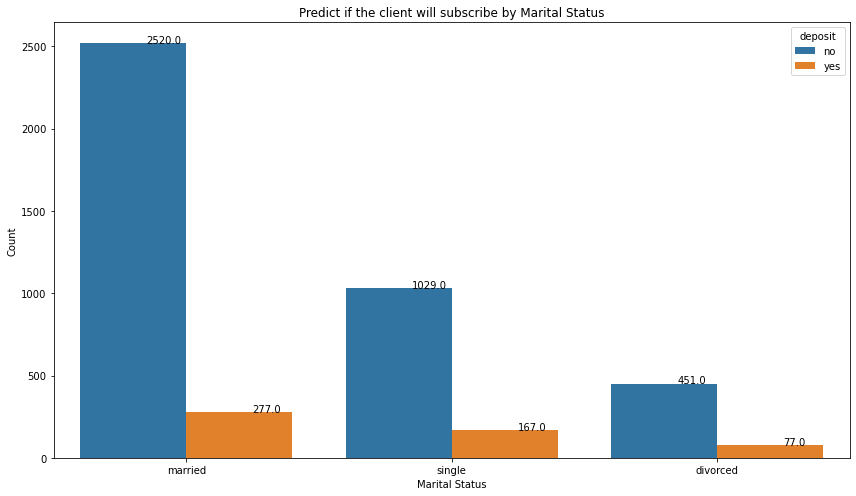

In [19]:
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.autolayout"] = True
ax = sns.countplot(x ='marital', hue = "deposit", data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status')

for p in ax.patches:
   ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

# Setting the X and Y labels
ax.set_xlabel('Marital Status')
ax.set_ylabel('Count')
 
# Show the plot
plt.show()

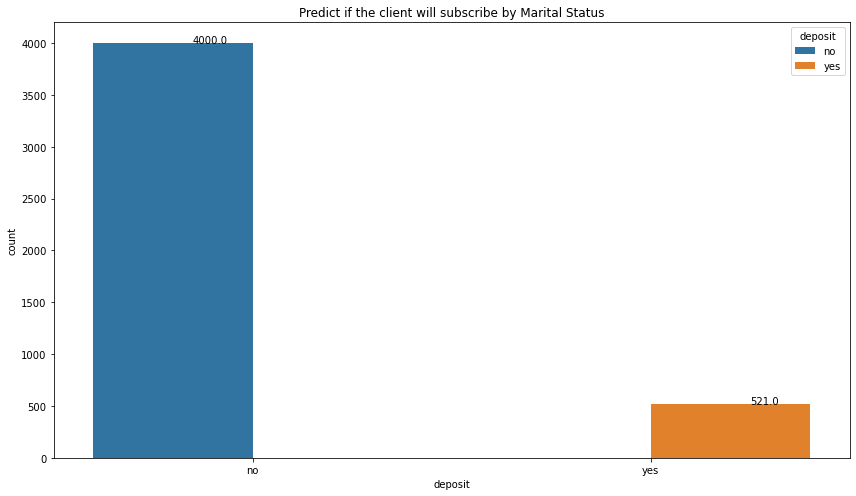

In [20]:
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.autolayout"] = True

# count plot on two categorical variable
ax = sns.countplot(x ='deposit', hue = "deposit", data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status')

for p in ax.patches:
   ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
 
# Show the plot
plt.show()

In [21]:
#Clean data with no nulls
df.isna().any()

age          False
job          False
marital      False
education    False
default      False
balance      False
housing      False
loan         False
contact      False
day          False
month        False
duration     False
campaign     False
pdays        False
previous     False
poutcome     False
deposit      False
dtype: bool

In [22]:
#df['age'].value_counts()

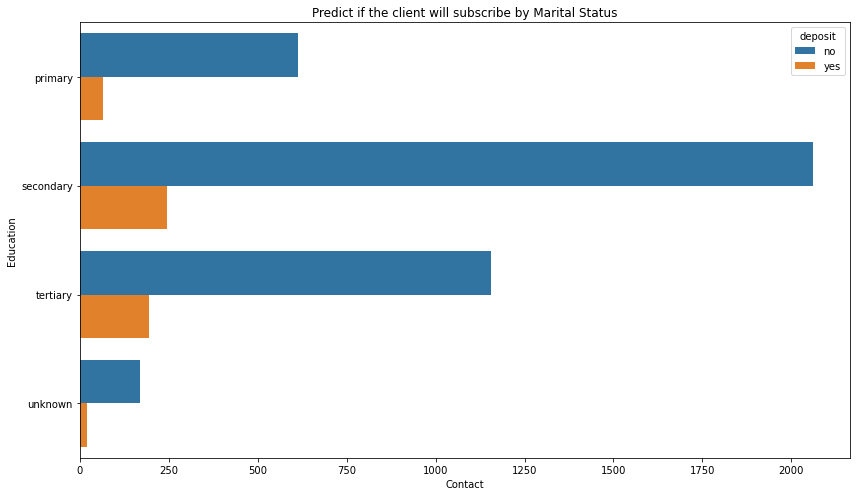

In [23]:
# Bar plot of count of accepted term deposit application by Education
ax = sns.countplot(y ='education', hue = "deposit", data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status')

# Setting the X and Y labels
ax.set_xlabel('Contact')
ax.set_ylabel('Education')

# Show the plot
plt.show()

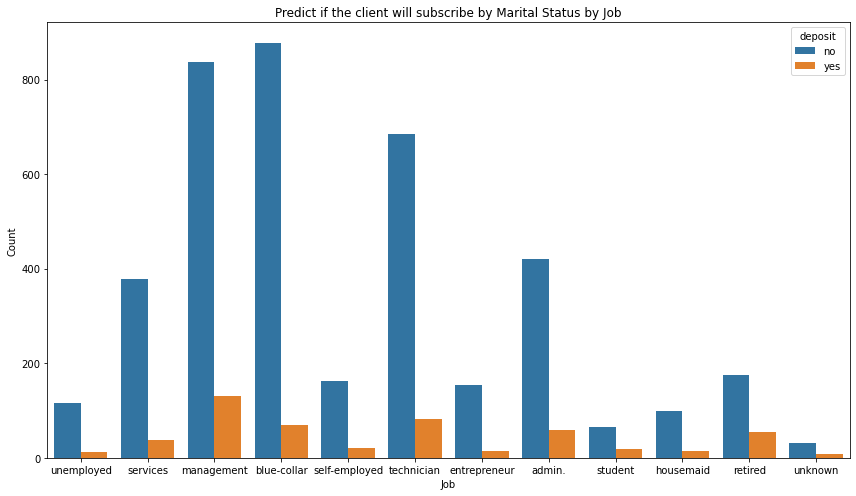

In [24]:
# Bar plot of count of accepted term deposit application by job
ax = sns.countplot(x ='job', hue = "deposit", data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status by Job')

# Setting the X and Y labels
ax.set_xlabel('Job')
ax.set_ylabel('Count')

# Show the plot
plt.show()

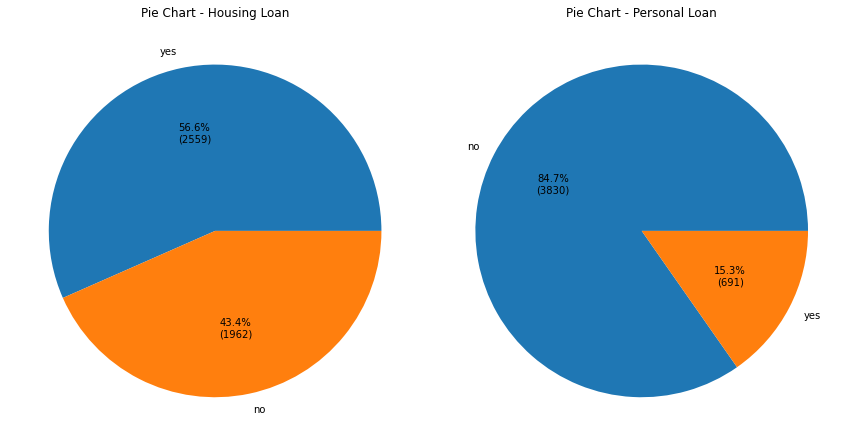

In [25]:
# Plot some pie charts to visualize the number of accepted term deposits by loan types in dataset
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

#plt.pie(df['LoanStatus'].value_counts().values, labels=df['LoanStatus'].value_counts().index, autopct=fmt)

# create a figure with two subplots
#fig, ax = plt.subplots(figsize=(12,8))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

# plot each pie chart in a separate subplot

ax1.set_title('Pie Chart - Housing Loan')
s = df['housing'].value_counts()
ax1.pie(s,labels = s.index,  autopct=autopct_format(s))

ax2.set_title('Pie Chart - Personal Loan')
s1 = df['loan'].value_counts()
ax2.pie(s1,labels = s1.index, autopct=autopct_format(s1))

plt.show()

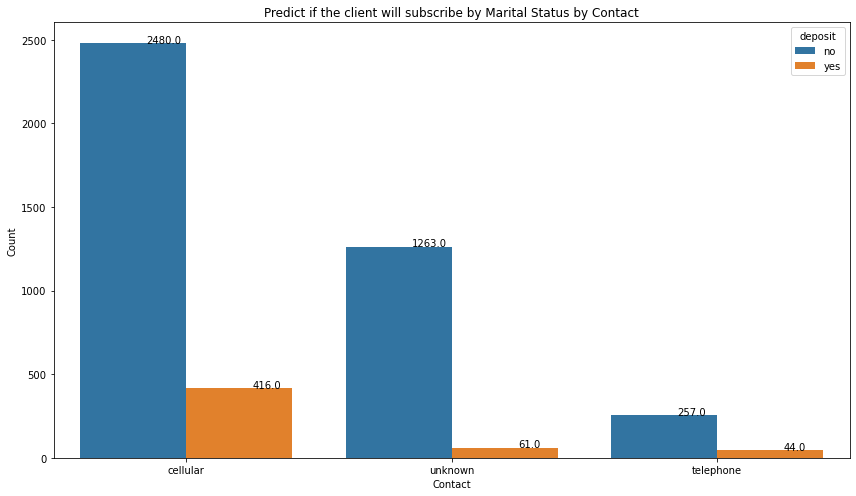

In [27]:
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.autolayout"] = True
ax = sns.countplot(x ='contact', hue = "deposit", data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status by Contact')

for p in ax.patches:
   ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

# Setting the X and Y labels
ax.set_xlabel('Contact')
ax.set_ylabel('Count')
 
# Show the plot
plt.show()

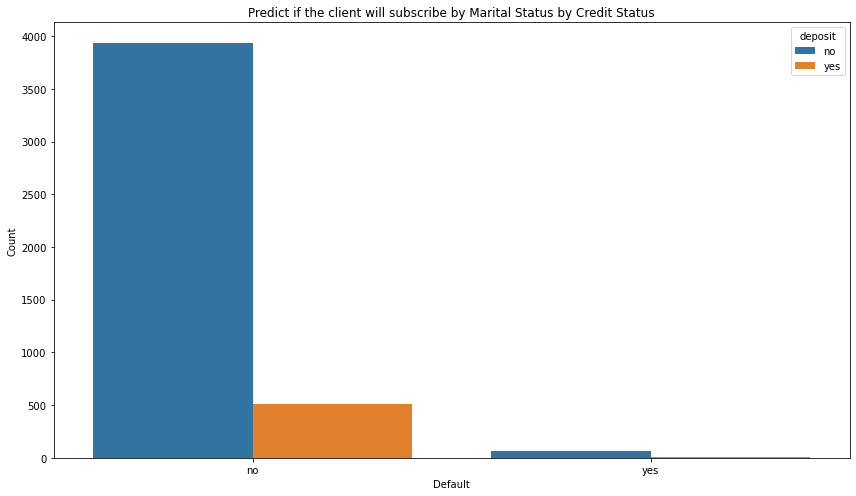

In [28]:
# Bar plot of count of accepted term deposit application by job
ax = sns.countplot(x ='default', hue = "deposit", data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status by Credit Status')

# Setting the X and Y labels
ax.set_xlabel('Default')
ax.set_ylabel('Count')

# Show the plot
plt.show()

In [29]:
df['default'].value_counts()

no     4445
yes      76
Name: default, dtype: int64

In [30]:
# Create a new df with customers where deposit = yes
#bank_df = df.query("deposit = yes")
value='yes'
bank_df=df.query("deposit == @value")
bank_df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
33,32,management,single,tertiary,no,2536,yes,no,cellular,26,aug,958,6,-1,0,unknown,yes
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
37,32,blue-collar,married,secondary,no,2089,yes,no,cellular,14,nov,132,1,-1,0,unknown,yes
38,33,management,married,secondary,no,3935,yes,no,cellular,6,may,765,1,342,2,failure,yes
49,61,admin.,married,unknown,no,4629,yes,no,cellular,27,jan,181,1,92,1,success,yes
50,45,blue-collar,divorced,primary,no,844,no,no,unknown,5,jun,1018,3,-1,0,unknown,yes
53,34,technician,married,tertiary,no,1539,yes,no,cellular,15,jun,441,1,56,1,other,yes


In [31]:
print('Number of Successful campaign records', bank_df.shape)

Number of Successful campaign records (521, 17)


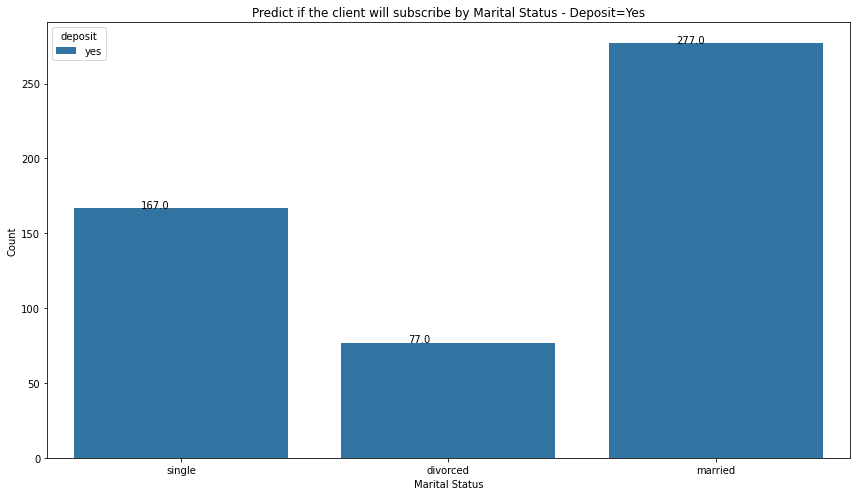

In [32]:
# Let plot a bar chart of the
# count plot on two categorical variable

plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.autolayout"] = True
ax = sns.countplot(x =bank_df['marital'], hue = bank_df["deposit"], data = df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Marital Status - Deposit=Yes')

for p in ax.patches:
   ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

# Setting the X and Y labels
ax.set_xlabel('Marital Status')
ax.set_ylabel('Count')
 
# Show the plot
plt.show()

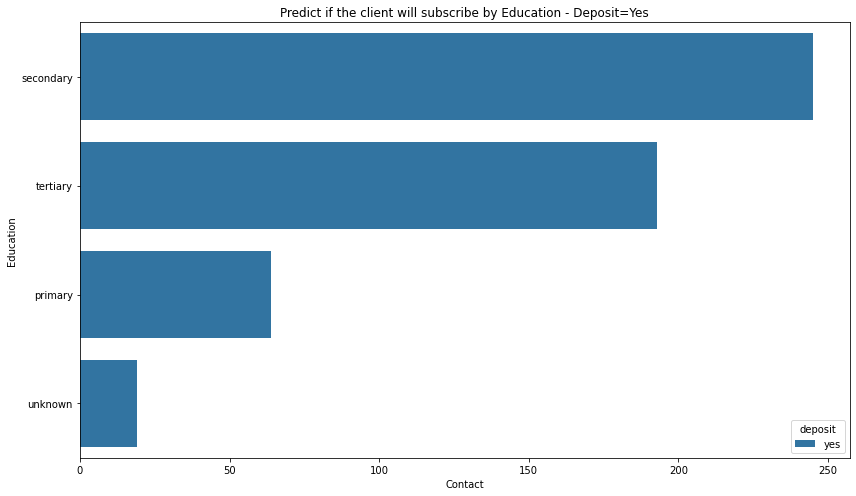

In [34]:
# Bar plot of count of accepted term deposit application by Education
ax = sns.countplot(y ='education', hue = "deposit", data = bank_df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Education - Deposit=Yes')

# Setting the X and Y labels
ax.set_xlabel('Contact')
ax.set_ylabel('Education')

# Show the plot
plt.show()

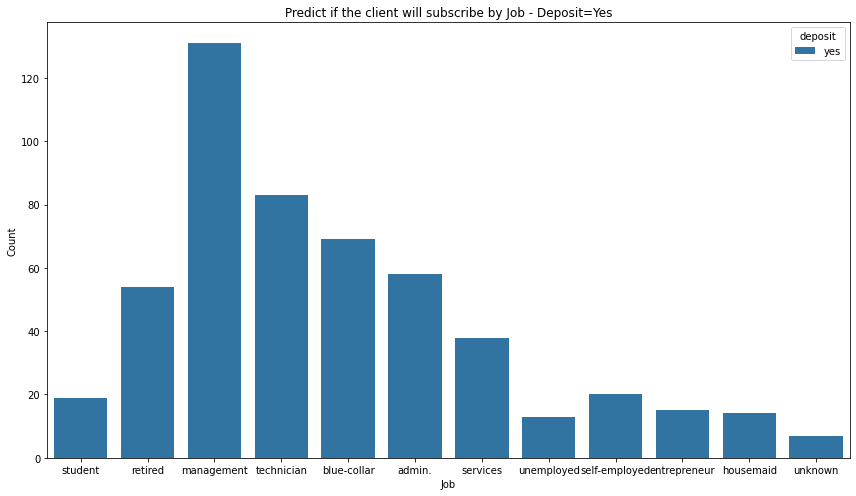

In [35]:
# Bar plot of count of accepted term deposit application by job
ax = sns.countplot(x ='job', hue = "deposit", data = bank_df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Job - Deposit=Yes')

# Setting the X and Y labels
ax.set_xlabel('Job')
ax.set_ylabel('Count')

# Show the plot
plt.show()

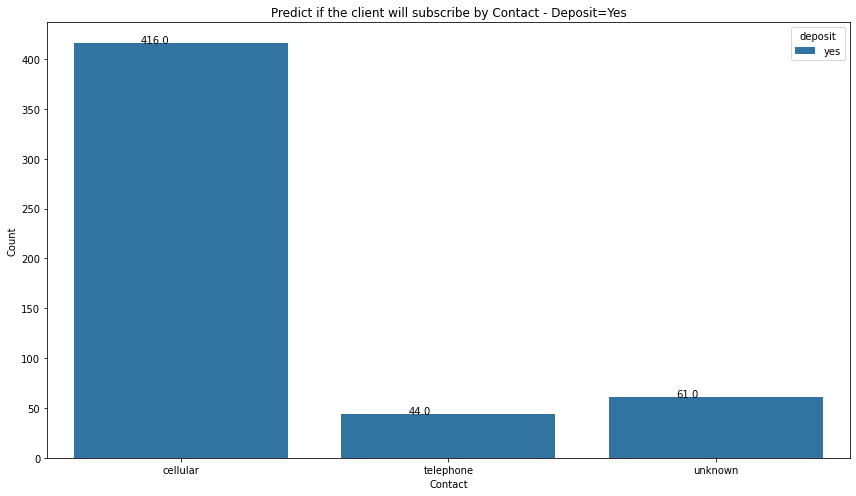

In [36]:
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.autolayout"] = True
ax = sns.countplot(x ='contact', hue = "deposit", data = bank_df)

# Adding Title to the Plot
ax.set_title('Predict if the client will subscribe by Contact - Deposit=Yes')

for p in ax.patches:
   ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

# Setting the X and Y labels
ax.set_xlabel('Contact')
ax.set_ylabel('Count')
 
# Show the plot
plt.show()